In [ ]:
# EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load clean data
master = pd.read_csv('../data/master_data.csv')
sales  = pd.read_csv('../data/sales_clean.csv')

# Fix date column
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])

print("Master shape:", master.shape)
print("Sales shape: ", sales.shape)
print("\nMaster columns:", master.columns.tolist())
print("Sales columns:", sales.columns.tolist() )
print(master.dtypes)
print(sales.dtypes)

Master shape: (3834, 12)
Sales shape:  (325725, 9)

Master columns: ['CustomerID', 'response', 'n_comp', 'loyalty', 'nps', 'n_communications', 'Total_Spending', 'Purchase_Frequency', 'Recency', 'Unique_Products', 'Avg_Basket_Size', 'nps_group']
Sales columns: ['CustomerID', 'InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'Country', 'TotalSales']
CustomerID              int64
response                int64
n_comp                  int64
loyalty                 int64
nps                   float64
n_communications        int64
Total_Spending        float64
Purchase_Frequency    float64
Recency               float64
Unique_Products       float64
Avg_Basket_Size       float64
nps_group              object
dtype: object
CustomerID              int64
InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
Country                object
Total

In [ ]:
# Box-Whisker Plots by Response

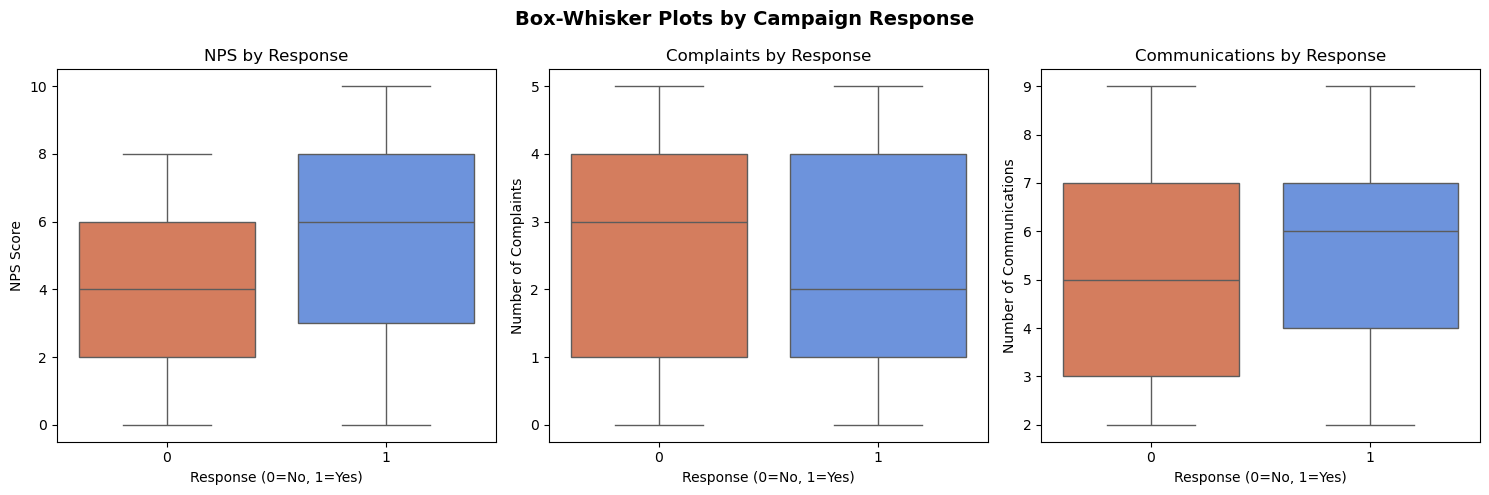

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 - NPS by Response
sns.boxplot(x='response', y='nps',
            data=master, ax=axes[0],
            hue='response',
            palette=['#e8734a','#5b8dee'],
            legend=False)
axes[0].set_title('NPS by Response')
axes[0].set_xlabel('Response (0=No, 1=Yes)')
axes[0].set_ylabel('NPS Score')

# Plot 2 - Complaints by Response
sns.boxplot(x='response', y='n_comp',
            data=master, ax=axes[1],
            hue='response',
            palette=['#e8734a','#5b8dee'],
            legend=False)
axes[1].set_title('Complaints by Response')
axes[1].set_xlabel('Response (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Complaints')

# Plot 3 - Communications by Response
sns.boxplot(x='response', y='n_communications',
            data=master, ax=axes[2],
            hue='response',
            palette=['#e8734a','#5b8dee'],
            legend=False)
axes[2].set_title('Communications by Response')
axes[2].set_xlabel('Response (0=No, 1=Yes)')
axes[2].set_ylabel('Number of Communications')

plt.suptitle('Box-Whisker Plots by Campaign Response',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/boxplots_response.png', dpi=150)
plt.show()


In [10]:
# ================================================
# Task 2 — Response Rate Tables
# ================================================

# Table 1 - Response Rate by Loyalty
loyalty_table = master.groupby('loyalty')['response'].agg(
    N='count',
    N_plus='sum'
).reset_index()
loyalty_table['RR%'] = (loyalty_table['N_plus'] / loyalty_table['N'] * 100).round(1)
loyalty_table['loyalty'] = loyalty_table['loyalty'].map({0: 'Not Loyal', 1: 'Loyal'})

print("=== Response Rate by Loyalty ===")
print(loyalty_table.to_string(index=False))

# Table 2 - Response Rate by NPS Group
nps_table = master.groupby('nps_group')['response'].agg(
    N='count',
    N_plus='sum'
).reset_index()
nps_table['RR%'] = (nps_table['N_plus'] / nps_table['N'] * 100).round(1)

print("\n=== Response Rate by NPS Group ===")
print(nps_table.to_string(index=False))

# Table 3 - Response Rate by n_comp
comp_table = master.groupby('n_comp')['response'].agg(
    N='count',
    N_plus='sum'
).reset_index()
comp_table['RR%'] = (comp_table['N_plus'] / comp_table['N'] * 100).round(1)

print("\n=== Response Rate by Number of Complaints ===")
print(comp_table.to_string(index=False))

=== Response Rate by Loyalty ===
  loyalty    N  N_plus  RR%
Not Loyal 1648     525 31.9
    Loyal 2186    1030 47.1

=== Response Rate by NPS Group ===
nps_group    N  N_plus   RR%
    Happy  261     261 100.0
  Neutral  776     346  44.6
  Unhappy 2797     948  33.9

=== Response Rate by Number of Complaints ===
 n_comp   N  N_plus  RR%
      0 377     157 41.6
      1 641     275 42.9
      2 785     377 48.0
      3 852     296 34.7
      4 778     326 41.9
      5 401     124 30.9
